# Classical and modified Williamson–Hall

This notebook applies the staged Dippa workflow to all nine nickel samples: rough-start peak re-fit, integral breadth, nearest-position instrumental subtraction, and then classical/mwhA/mwhB/mwhC fitting. HKLs are assigned explicitly; nothing auto-indexes the peaks.

The Nickel `ch00` below is computed from the two values used by the original `startup_WHpref.m` GUI preset. No q value from the literature is supplied as truth: q is fitted from these data, and the reported confidence intervals and low-DoF warnings are the deliverable.


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np

from dippa import (
    Phase,
    Reflection,
    bind_reflections,
    delta_k,
    fit_williamson_hall,
    format_hkil,
    load_matlab_samples,
)
from dippa.background import fit_background_quadratic
from dippa.fitting import fit_pattern

DATA_PATH = Path("../data/ni_combo.mat")
SAMPLES = load_matlab_samples(DATA_PATH)
PHASE = Phase("FCC", a=3.53)
HKL = [
    Reflection(1, 1, 1),
    Reflection(2, 0, 0),
    Reflection(2, 2, 0),
    Reflection(3, 1, 1),
    Reflection(2, 2, 2),
]
HKL_LABELS = [format_hkil(reflection, PHASE.cstruct) for reflection in HKL]
CH00 = float(np.mean([0.289, 0.279]))


def rough_start(sample, seed):
    x, y = sample.data[:, 0], sample.data[:, 1]
    aa = sample.aa.copy()
    rng = np.random.default_rng(seed)
    for peak in range(sample.n_peaks):
        aa[0, peak] += rng.uniform(-0.005, 0.005)
        aa[1, peak] *= rng.uniform(0.5, 1.5)
        aa[2, peak] = aa[4, peak] = 0.002
        aa[3, peak] = aa[5, peak] = 0.5
    aa[:3, -1] = fit_background_quadratic(
        x, y, aa[0, :sample.n_peaks], half_width=0.02
    )
    return aa


print(f"Loaded {len(SAMPLES)} samples; explicit reflections: {', '.join(HKL_LABELS)}")
print(f"Nickel GUI-preset ch00 = mean(0.289, 0.279) = {CH00:.6f}")


Loaded 9 samples; explicit reflections: (111), (200), (220), (311), (222)
Nickel GUI-preset ch00 = mean(0.289, 0.279) = 0.284000


## Peak re-fit and instrumental subtraction

Integral breadth is used throughout. Flagged peak fits are excluded by default. Nonpositive sample-minus-instrument breadths are dropped with an explicit warning and retained in each result's exclusion report.


In [2]:
PEAK_FITS = []
CORRECTIONS = []
BINDINGS = []
for sample_index, sample in enumerate(SAMPLES):
    peak_fit = fit_pattern(
        sample.data[:, 0],
        sample.data[:, 1],
        rough_start(sample, seed=42 + sample_index),
        half_width=0.02,
        tube="Co",
        n_passes=3,
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", UserWarning)
        correction = delta_k(
            peak_fit, sample.aa_I, kind="IB", drop_nonpositive=True
        )
    PEAK_FITS.append(peak_fit)
    CORRECTIONS.append(correction)
    BINDINGS.append(
        bind_reflections(peak_fit.aa[0, :-1], PHASE, HKL, tol=0.001)
    )

print(f"{'sample':<18} {'retained':>8}  exclusions")
print("-" * 80)
for sample, correction in zip(SAMPLES, CORRECTIONS):
    excluded = [
        f"{HKL_LABELS[item.peak_index]}: {', '.join(item.reasons)}"
        for item in correction.excluded_peaks
    ]
    print(f"{sample.name:<18} {len(correction.delta_k):>8}  {excluded or 'none'}")


sample             retained  exclusions
--------------------------------------------------------------------------------
niHmid_halfpc             2  ['(111): nonpositive delta_k', '(311): at upper bound: eta_left', '(222): at upper bound: eta_left']
niE_mid_12pc              5  none
niF_mid_4pc               5  none
niC_24pc                  5  none
niB_mid_3pc               5  none
niD_mid_17pc              5  none
ni_new_10pc               5  none
ni_30pc_allp              5  none
ni2pc_new                 5  none


## The half-percent exclusion case

This is deliberately asserted rather than merely plotted: the negative corrected (111) breadth and the eta-bound warnings on (311)/(222) must remain visible in the policy result, and none may enter a three-parameter fit.


In [3]:
halfpc = CORRECTIONS[0]
halfpc_excluded = {item.peak_index: item.reasons for item in halfpc.excluded_peaks}
assert set(halfpc_excluded) == {0, 3, 4}
assert "nonpositive delta_k" in halfpc_excluded[0]
assert all("upper bound" in halfpc_excluded[index][0] for index in (3, 4))
assert len(halfpc.delta_k) < 3
for peak_index, reasons in halfpc_excluded.items():
    print(f"excluded {HKL_LABELS[peak_index]}: {', '.join(reasons)}")
print(f"retained points = {len(halfpc.delta_k)}; mWH fit intentionally not attempted")


excluded (111): nonpositive delta_k
excluded (311): at upper bound: eta_left
excluded (222): at upper bound: eta_left
retained points = 2; mWH fit intentionally not attempted


## Four model forms on one sample

Every parameter and interval printed below comes from the result object. With only five reflections, modified fits have two degrees of freedom, so their low-DoF warnings are expected and material to interpretation.


sample: ni_new_10pc
variant    q [95% CI]                         size [95% CI]                          strain [95% CI]
----------------------------------------------------------------------------------------------------------------------------------
classical  0 [0, 0]  6.96849e-05 [-0.00105747, 0.00119684]  0.00176722 [-0.000940622, 0.00447507]
  n=5, DoF=3, warnings=none
mwhA       1.99074 [1.42928, 2.55219]  1.65146e-12 [-0.000300473, 0.000300473]  0.00266243 [0.00179248, 0.00353237]
  n=5, DoF=2, warnings=('low degrees of freedom: 2; confidence intervals are fragile', 'parameters at lower bound: size')
mwhB       1.99238 [1.44208, 2.54268]  3.12343e-06 [-0.0285035, 0.0285098]  0.002662 [0.00223851, 0.00308549]
  n=5, DoF=2, warnings=('low degrees of freedom: 2; confidence intervals are fragile',)
mwhC       1.87225 [1.35732, 2.38719]  0.000291689 [0.000109308, 0.00047407]  0.00494988 [0.00334997, 0.00654979]
  n=5, DoF=2, warnings=('low degrees of freedom: 2; confidence intervals

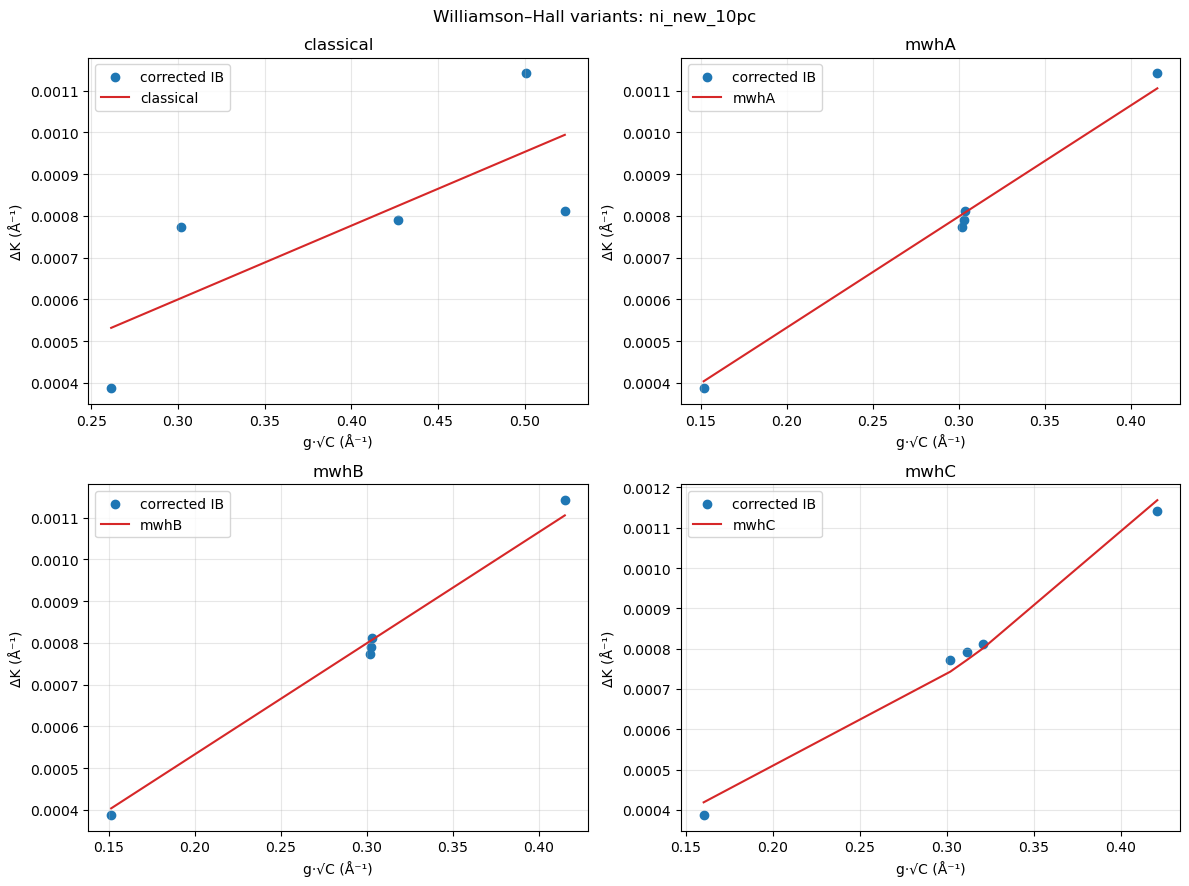

In [4]:
DEMO_INDEX = next(i for i, sample in enumerate(SAMPLES) if sample.name == "ni_new_10pc")
VARIANTS = ["classical", "mwhA", "mwhB", "mwhC"]
VARIANT_RESULTS = {
    variant: fit_williamson_hall(
        CORRECTIONS[DEMO_INDEX], BINDINGS[DEMO_INDEX], CH00, variant=variant
    )
    for variant in VARIANTS
}

print(f"sample: {SAMPLES[DEMO_INDEX].name}")
print(f"{'variant':<10} {'q [95% CI]':<34} {'size [95% CI]':<38} {'strain [95% CI]'}")
print("-" * 130)
for variant, result in VARIANT_RESULTS.items():
    p, ci = result.parameters, result.confidence_intervals
    print(
        f"{variant:<10} {p.q:.6g} [{ci.q[0]:.6g}, {ci.q[1]:.6g}]  "
        f"{p.size:.6g} [{ci.size[0]:.6g}, {ci.size[1]:.6g}]  "
        f"{p.strain:.6g} [{ci.strain[0]:.6g}, {ci.strain[1]:.6g}]"
    )
    print(f"  n={result.n_points}, DoF={result.dof}, warnings={result.warnings or 'none'}")

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (variant, result) in zip(axes.flat, VARIANT_RESULTS.items()):
    order = np.argsort(result.x)
    ax.scatter(result.x, CORRECTIONS[DEMO_INDEX].delta_k, label="corrected IB")
    ax.plot(result.x[order], result.fitted_delta_k[order], color="tab:red", label=variant)
    ax.set_title(variant)
    ax.set_xlabel("g·√C (Å⁻¹)")
    ax.set_ylabel("ΔK (Å⁻¹)")
    ax.grid(alpha=0.3)
    ax.legend()
fig.suptitle(f"Williamson–Hall variants: {SAMPLES[DEMO_INDEX].name}")
plt.tight_layout()
plt.show()


## mwhA across the strain series

The half-percent sample remains in the report as an explicit non-fit because its policies leave too few points. Trends are shown with Jacobian-based 95% confidence intervals; no comparison to paper q values is encoded here.


sample             strain axis q [95% CI]                         size [95% CI]                          strain [95% CI]
--------------------------------------------------------------------------------------------------------------------------------------------
niHmid_halfpc           83.409 not fit: 2 retained points
niE_mid_12pc           363.470 1.81778 [0.431705, 3.20385]  0.00013312 [-0.000686888, 0.000953128]  0.00317504 [0.000794196, 0.00555588]
niF_mid_4pc            200.665 2.25917 [-1.06916, 5.58751]  0.000112202 [-0.000932765, 0.00115717]  0.001382 [-0.00164301, 0.00440702]
niC_24pc               489.184 0.572074 [-5.7218, 6.86595]  0.000326091 [-0.00211293, 0.00276511]  0.00352917 [-0.00375023, 0.0108086]
niB_mid_3pc            184.029 -0.250396 [-39.6051, 39.1043]  0.000559019 [1.31397e-05, 0.0011049]  0.000171569 [-0.00148775, 0.00183089]
niD_mid_17pc           427.038 0.826451 [-2.75774, 4.41064]  9.53417e-10 [-0.00177587, 0.00177587]  0.00406523 [-0.00120113, 0.0093316]

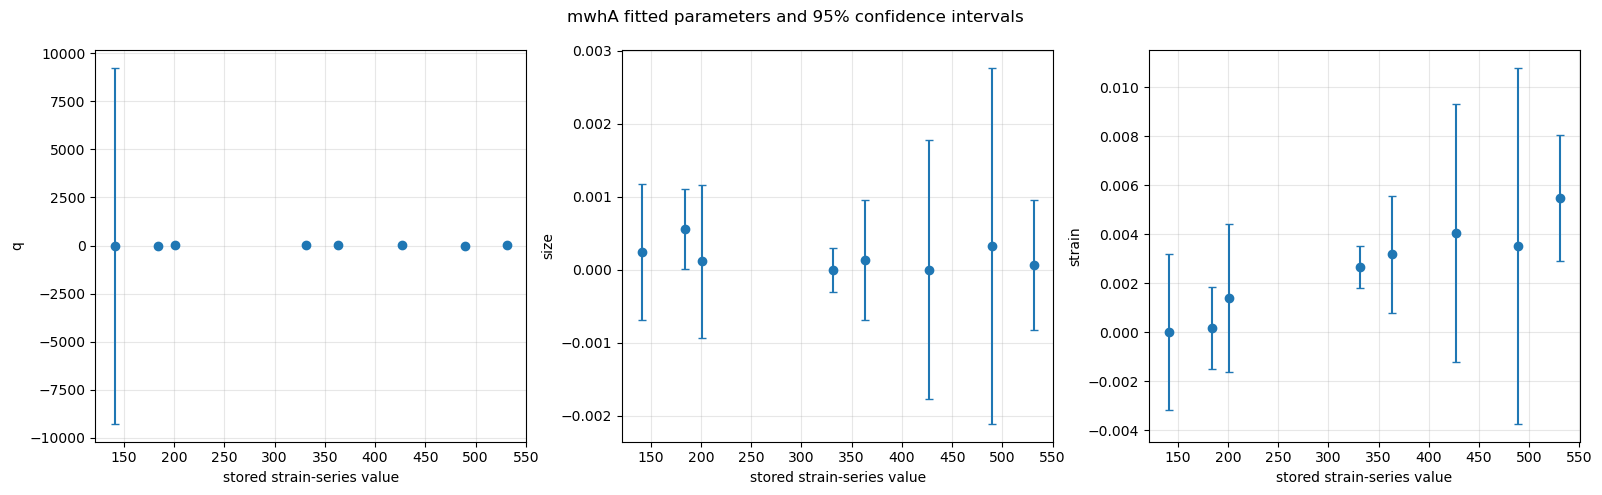

In [5]:
SERIES_RESULTS = []
for sample, correction, binding in zip(SAMPLES, CORRECTIONS, BINDINGS):
    result = (
        fit_williamson_hall(correction, binding, CH00, variant="mwhA")
        if len(correction.delta_k) >= 3
        else None
    )
    SERIES_RESULTS.append(result)

print(f"{'sample':<18} {'strain axis':>11} {'q [95% CI]':<34} {'size [95% CI]':<38} strain [95% CI]")
print("-" * 140)
for sample, correction, result in zip(SAMPLES, CORRECTIONS, SERIES_RESULTS):
    if result is None:
        print(f"{sample.name:<18} {sample.valstrain:>11.3f} not fit: {len(correction.delta_k)} retained points")
        continue
    p, ci = result.parameters, result.confidence_intervals
    print(
        f"{sample.name:<18} {sample.valstrain:>11.3f} "
        f"{p.q:.6g} [{ci.q[0]:.6g}, {ci.q[1]:.6g}]  "
        f"{p.size:.6g} [{ci.size[0]:.6g}, {ci.size[1]:.6g}]  "
        f"{p.strain:.6g} [{ci.strain[0]:.6g}, {ci.strain[1]:.6g}]"
    )

valid = [(sample, result) for sample, result in zip(SAMPLES, SERIES_RESULTS) if result]
axis_values = np.array([sample.valstrain for sample, _ in valid])
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, name in zip(axes, ["q", "size", "strain"]):
    estimates = np.array([getattr(result.parameters, name) for _, result in valid])
    intervals = np.array([getattr(result.confidence_intervals, name) for _, result in valid])
    errors = np.vstack((estimates - intervals[:, 0], intervals[:, 1] - estimates))
    ax.errorbar(axis_values, estimates, yerr=errors, fmt="o", capsize=3)
    ax.set_xlabel("stored strain-series value")
    ax.set_ylabel(name)
    ax.grid(alpha=0.3)
fig.suptitle("mwhA fitted parameters and 95% confidence intervals")
plt.tight_layout()
plt.show()
